In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv('telecom_churn.csv')

In [30]:
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [31]:
df.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='object')

In [32]:
df.rename(columns={'OverageFee': 'AverageFee'}, inplace=True)

In [33]:
df.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
AverageFee         0
RoamMins           0
dtype: int64

In [34]:
df.shape

(3333, 11)

In [35]:
df['Churn'].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

In [36]:
df.duplicated().value_counts()

False    3333
Name: count, dtype: int64

In [37]:
df.dtypes

Churn                int64
AccountWeeks         int64
ContractRenewal      int64
DataPlan             int64
DataUsage          float64
CustServCalls        int64
DayMins            float64
DayCalls             int64
MonthlyCharge      float64
AverageFee         float64
RoamMins           float64
dtype: object

In [38]:
df.groupby('Churn').mean(numeric_only=True)

,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,AverageFee,RoamMins
Churn,,,,,,,,,,
0,100.793684,0.934737,0.295439,0.862151,1.449825,175.175754,100.283158,55.816246,9.954618,10.158877
1,102.664596,0.716356,0.165631,0.546957,2.229814,206.914079,101.335404,59.190062,10.623085,10.700000


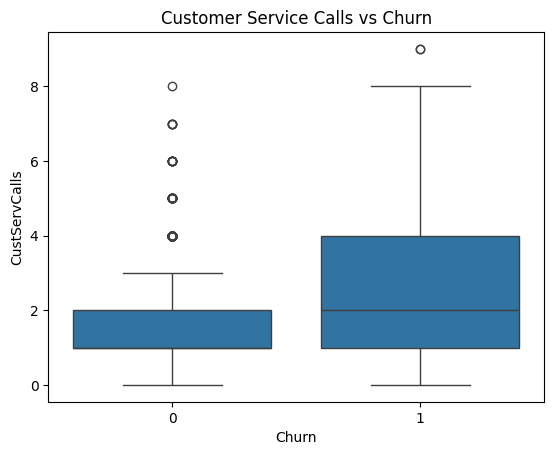

In [39]:
sns.boxplot(data=df, x='Churn', y='CustServCalls')
plt.title('Customer Service Calls vs Churn')
plt.show()

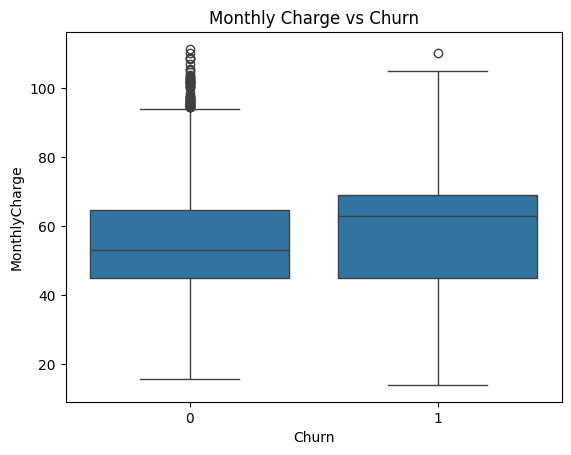

In [40]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharge')
plt.title('Monthly Charge vs Churn')
plt.show()

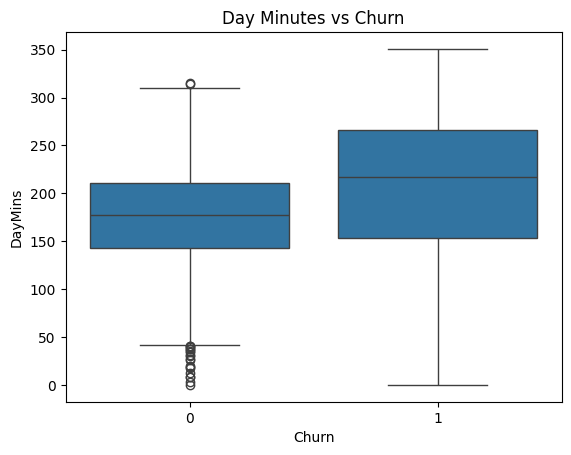

In [41]:
sns.boxplot(data=df, x='Churn', y='DayMins')
plt.title('Day Minutes vs Churn')
plt.show()

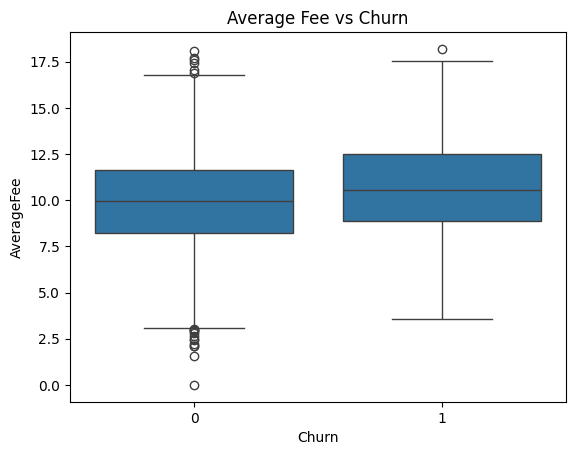

In [44]:
sns.boxplot(data=df, x='Churn', y='AverageFee')
plt.title('Average Fee vs Churn')
plt.show()

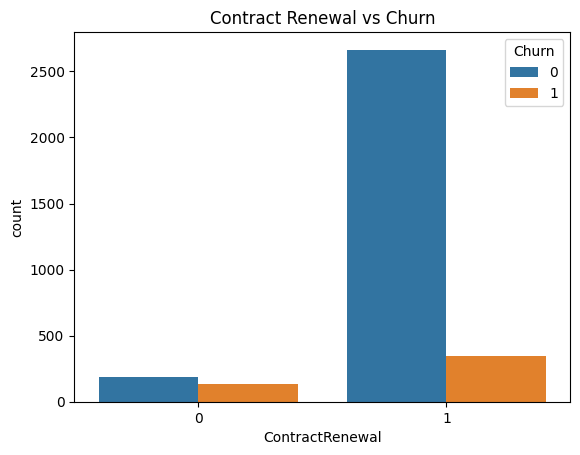

In [45]:
sns.countplot(data=df, x='ContractRenewal', hue='Churn')
plt.title('Contract Renewal vs Churn')
plt.show()

In [46]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [47]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3333, 10)
y shape: (3333,)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [49]:
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training distribution:
Churn
0    0.855214
1    0.144786
Name: proportion, dtype: float64

Testing distribution:
Churn
0    0.854573
1    0.145427
Name: proportion, dtype: float64


In [50]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])
logistic_model.fit(X_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [51]:
logistic_pred = logistic_model.predict(X_test)
logistic_proba = logistic_model.predict_proba(X_test)[:, 1]

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model_name, y_true, y_pred, y_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_proba)

    print(f"\n{'='*50}")
    print(model_name)
    print(f"{'='*50}")

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return {
            'Model': model_name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc
        }

In [53]:
results = []

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_proba
)

results.append(logistic_results)


Logistic Regression
Accuracy:  0.8576
Precision: 0.5263
Recall:    0.2062
F1 Score:  0.2963
ROC-AUC:   0.5873
PR-AUC:    0.4165

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       570
           1       0.53      0.21      0.30        97

    accuracy                           0.86       667
   macro avg       0.70      0.59      0.61       667
weighted avg       0.83      0.86      0.83       667

Confusion Matrix:
[[552  18]
 [ 77  20]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
dt_pred = tree.predict(X_test)
dt_proba = tree.predict_proba(X_test)[:, 1]

In [57]:
dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_proba
)
results.append(dt_results)


Decision Tree
Accuracy:  0.8921
Precision: 0.6404
Recall:    0.5876
F1 Score:  0.6129
ROC-AUC:   0.7657
PR-AUC:    0.4363

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       570
           1       0.64      0.59      0.61        97

    accuracy                           0.89       667
   macro avg       0.79      0.77      0.78       667
weighted avg       0.89      0.89      0.89       667

Confusion Matrix:
[[538  32]
 [ 40  57]]


In [61]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    random_state=42,
    n_estimators=300,
    n_jobs=-1
)
random_forest.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [62]:
rf_pred = random_forest.predict(X_test)
rf_proba = random_forest.predict_proba(X_test)[:, 1]

In [63]:
rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_proba
)

results.append(rf_results)


Random Forest
Accuracy:  0.9280
Precision: 0.8182
Recall:    0.6495
F1 Score:  0.7241
ROC-AUC:   0.8125
PR-AUC:    0.7407

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.82      0.65      0.72        97

    accuracy                           0.93       667
   macro avg       0.88      0.81      0.84       667
weighted avg       0.92      0.93      0.92       667

Confusion Matrix:
[[556  14]
 [ 34  63]]


In [64]:
from sklearn.ensemble import BaggingClassifier

bagging = BaggingClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)

,estimator,None
,n_estimators,200
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


In [65]:
bagging_pred = bagging.predict(X_test)
bagging_proba = bagging.predict_proba(X_test)[:, 1]

In [66]:
bagging_results = evaluate_model(
    "Bagging",
    y_test,
    bagging_pred,
    bagging_proba
)

results.append(bagging_results)


Bagging
Accuracy:  0.9265
Precision: 0.8333
Recall:    0.6186
F1 Score:  0.7101
ROC-AUC:   0.7988
PR-AUC:    0.7253

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.83      0.62      0.71        97

    accuracy                           0.93       667
   macro avg       0.89      0.80      0.83       667
weighted avg       0.92      0.93      0.92       667

Confusion Matrix:
[[558  12]
 [ 37  60]]


In [67]:
from sklearn.ensemble import AdaBoostClassifier

adaboost = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.5,
    random_state=42
)

adaboost.fit(X_train, y_train)

,estimator,None
,n_estimators,200
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42


In [68]:
ada_pred = adaboost.predict(X_test)
ada_proba = adaboost.predict_proba(X_test)[:, 1]

In [69]:
ada_results = evaluate_model(
    "AdaBoost",
    y_test,
    ada_pred,
    ada_proba
)

results.append(ada_results)


AdaBoost
Accuracy:  0.8741
Precision: 0.6327
Recall:    0.3196
F1 Score:  0.4247
ROC-AUC:   0.6440
PR-AUC:    0.5868

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       570
           1       0.63      0.32      0.42        97

    accuracy                           0.87       667
   macro avg       0.76      0.64      0.68       667
weighted avg       0.86      0.87      0.86       667

Confusion Matrix:
[[552  18]
 [ 66  31]]


In [70]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [71]:
gb_pred = gradient_boosting.predict(X_test)
gb_proba = gradient_boosting.predict_proba(X_test)[:, 1]

In [72]:
gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_pred,
    gb_proba
)

results.append(gb_results)


Gradient Boosting
Accuracy:  0.9235
Precision: 0.7875
Recall:    0.6495
F1 Score:  0.7119
ROC-AUC:   0.8098
PR-AUC:    0.7478

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       570
           1       0.79      0.65      0.71        97

    accuracy                           0.92       667
   macro avg       0.86      0.81      0.83       667
weighted avg       0.92      0.92      0.92       667

Confusion Matrix:
[[553  17]
 [ 34  63]]


# Compare All Models

In [73]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.857571,0.526316,0.206186,0.296296,0.587303,0.416491
1,Decision Tree,0.892054,0.640449,0.587629,0.612903,0.765744,0.436317
2,Decision Tree,0.892054,0.640449,0.587629,0.612903,0.765744,0.436317
3,Random Forest,0.928036,0.826667,0.639175,0.720930,0.808184,0.734114
4,Random Forest,0.928036,0.818182,0.649485,0.724138,0.812462,0.740709
5,Bagging,0.926537,0.833333,0.618557,0.710059,0.798752,0.725313
6,AdaBoost,0.874063,0.632653,0.319588,0.424658,0.644004,0.586765
7,Gradient Boosting,0.923538,0.787500,0.649485,0.711864,0.809830,0.747818


In [74]:
results_df.sort_values(
    by='F1',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
4,Random Forest,0.928036,0.818182,0.649485,0.724138,0.812462,0.740709
3,Random Forest,0.928036,0.826667,0.639175,0.720930,0.808184,0.734114
7,Gradient Boosting,0.923538,0.787500,0.649485,0.711864,0.809830,0.747818
5,Bagging,0.926537,0.833333,0.618557,0.710059,0.798752,0.725313
1,Decision Tree,0.892054,0.640449,0.587629,0.612903,0.765744,0.436317
2,Decision Tree,0.892054,0.640449,0.587629,0.612903,0.765744,0.436317
6,AdaBoost,0.874063,0.632653,0.319588,0.424658,0.644004,0.586765
0,Logistic Regression,0.857571,0.526316,0.206186,0.296296,0.587303,0.416491


In [75]:
results_df.sort_values(
    by='Recall',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
7,Gradient Boosting,0.923538,0.787500,0.649485,0.711864,0.809830,0.747818
4,Random Forest,0.928036,0.818182,0.649485,0.724138,0.812462,0.740709
3,Random Forest,0.928036,0.826667,0.639175,0.720930,0.808184,0.734114
5,Bagging,0.926537,0.833333,0.618557,0.710059,0.798752,0.725313
1,Decision Tree,0.892054,0.640449,0.587629,0.612903,0.765744,0.436317
2,Decision Tree,0.892054,0.640449,0.587629,0.612903,0.765744,0.436317
6,AdaBoost,0.874063,0.632653,0.319588,0.424658,0.644004,0.586765
0,Logistic Regression,0.857571,0.526316,0.206186,0.296296,0.587303,0.416491


# Cross Validation

In [76]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [77]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [78]:
logistic_cv = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("Logistic Regression CV F1:")
print(logistic_cv)
print("Mean:", logistic_cv.mean())

Logistic Regression CV F1:
[0.23140496 0.21311475 0.28571429 0.37142857 0.2601626 ]
Mean: 0.272365034308984


In [79]:
rf_cv = cross_val_score(
    random_forest,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("Random Forest CV F1:")
print(rf_cv)
print("Mean:", rf_cv.mean())

Random Forest CV F1:
[0.78106509 0.73809524 0.72392638 0.77173913 0.76190476]
Mean: 0.7553461199120555


In [80]:
gb_cv = cross_val_score(
    gradient_boosting,
    X,
    y,
    cv=cv,
    scoring='f1'
)

print("Gradient Boosting CV F1:")
print(gb_cv)
print("Mean:", gb_cv.mean())

Gradient Boosting CV F1:
[0.75151515 0.75903614 0.71604938 0.74033149 0.76300578]
Mean: 0.7459875901738084


# Hyperparameter Tuning

In [81]:
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [82]:
rf_grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [83]:
rf_grid.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [84]:
print("Best parameters:")
print(rf_grid.best_params_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [85]:
print("Best CV F1:")
print(rf_grid.best_score_)

Best CV F1:
0.762035080758485


In [86]:
best_rf = rf_grid.best_estimator_

In [87]:
best_rf_pred = best_rf.predict(X_test)
best_rf_proba = best_rf.predict_proba(X_test)[:, 1]

best_rf_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    best_rf_pred,
    best_rf_proba
)


Tuned Random Forest
Accuracy:  0.9235
Precision: 0.8026
Recall:    0.6289
F1 Score:  0.7052
ROC-AUC:   0.8013
PR-AUC:    0.7461

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       570
           1       0.80      0.63      0.71        97

    accuracy                           0.92       667
   macro avg       0.87      0.80      0.83       667
weighted avg       0.92      0.92      0.92       667

Confusion Matrix:
[[555  15]
 [ 36  61]]


# Gradient Boosting Hyperparameter Tuning

In [88]:
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [89]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(
        random_state=42
    ),
    param_grid=gb_params,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [90]:
gb_grid.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [91]:
print("Best parameters:")
print(gb_grid.best_params_)

Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [92]:
print("Best CV F1:")
print(gb_grid.best_score_)

Best CV F1:
0.7596474161489783


In [93]:
best_gb = gb_grid.best_estimator_

In [94]:
best_gb_pred = best_gb.predict(X_test)
best_gb_proba = best_gb.predict_proba(X_test)[:, 1]

best_gb_results = evaluate_model(
    "Tuned Gradient Boosting",
    y_test,
    best_gb_pred,
    best_gb_proba
)


Tuned Gradient Boosting
Accuracy:  0.9205
Precision: 0.7619
Recall:    0.6598
F1 Score:  0.7072
ROC-AUC:   0.8124
PR-AUC:    0.7402

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       570
           1       0.76      0.66      0.71        97

    accuracy                           0.92       667
   macro avg       0.85      0.81      0.83       667
weighted avg       0.92      0.92      0.92       667

Confusion Matrix:
[[550  20]
 [ 33  64]]


In [95]:
rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [96]:
rf_balanced_pred = rf_balanced.predict(X_test)
rf_balanced_proba = rf_balanced.predict_proba(X_test)[:, 1]

In [97]:
rf_balanced_results = evaluate_model(
    "Random Forest - Balanced",
    y_test,
    rf_balanced_pred,
    rf_balanced_proba
)


Random Forest - Balanced
Accuracy:  0.9250
Precision: 0.8219
Recall:    0.6186
F1 Score:  0.7059
ROC-AUC:   0.7979
PR-AUC:    0.7272

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.82      0.62      0.71        97

    accuracy                           0.93       667
   macro avg       0.88      0.80      0.83       667
weighted avg       0.92      0.93      0.92       667

Confusion Matrix:
[[557  13]
 [ 37  60]]
